In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop('Cabin', axis=1)
print('Data ready. Shape:', df.shape)

Data ready. Shape: (891, 11)


## Descriptive Statistics

In [2]:
age = df['Age']

print(f'Count : {len(age)}')
print(f'Mean : {age.mean():.2f}')
print(f'Median : {age.median():.2f}')
print(f'Mode : {age.mode()[0]:.2f}')
print(f'Std Dev : {age.std():.2f}')
print(f'Min : {age.min():.2f}')
print(f'Max : {age.max():.2f}')
print(f'Q1 : {age.quantile(0.25):.2f}')
print(f'Q3 : {age.quantile(0.75):.2f}')
print(f'IQR : {age.quantile(0.75)-age.quantile(0.25):.2f}')

Count : 891
Mean : 29.36
Median : 28.00
Mode : 28.00
Std Dev : 13.02
Min : 0.42
Max : 80.00
Q1 : 22.00
Q3 : 35.00
IQR : 13.00


## Mean vs Median - Why median is better for skewed data

In [3]:
# Simple example with salaries

salaries = [30000, 32000, 35000, 28000, 31000, 33000]

with_ceo = [30000,32000,35000,28000,31000,33000,5000000]

print('WITHOUT the CEO:')

print(f' Mean = {int(sum(salaries)/len(salaries)):,}')

print(f' Median = {int(sorted(salaries)[len(salaries)//2]):,}')

print(' WITH the CEO salaries added:')

print(f' Mean = {int(sum(with_ceo)/len(with_ceo)):,}')

print(f' Median = {int(sorted(with_ceo)[len(with_ceo)//2]):,}')

print()

print('RULE: Use MEDIAN when data has outliers.')
print('RULE: Use MEAN when data is symmetric.')
print()
print(f'Titanic Fare Mean = {df["Fare"].mean():.2f}')
print(f'Titanic Fare Median = {df["Fare"].median():.2f}')

WITHOUT the CEO:
 Mean = 31,500
 Median = 32,000
 WITH the CEO salaries added:
 Mean = 741,285
 Median = 32,000

RULE: Use MEDIAN when data has outliers.
RULE: Use MEAN when data is symmetric.

Titanic Fare Mean = 32.20
Titanic Fare Median = 14.45


## Visualise distributions - chart of Age and Fare

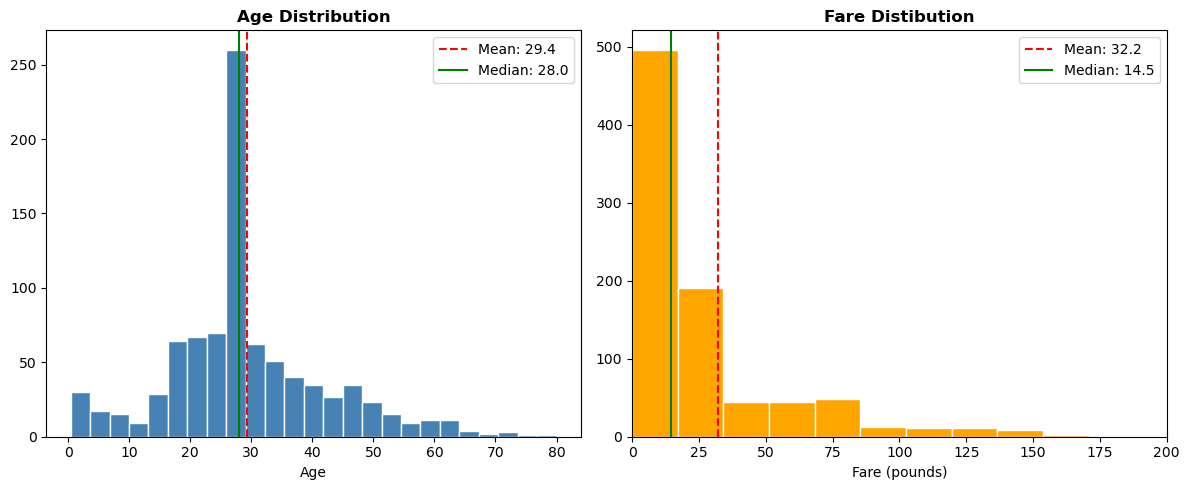

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Let chart : Age distribution

axes[0].hist(df['Age'], bins=25, color='steelblue', edgecolor='white')

axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')

axes[0].axvline(df['Age'].median(), color='green', linestyle='-', label=f'Median: {df["Age"].median():.1f}')

axes[0].set_title('Age Distribution', fontweight='bold')

axes[0].set_xlabel('Age')

axes[0].legend()

# Right chart : Fare distribution

axes[1].hist(df['Fare'], bins=30, color='orange', edgecolor='white')

axes[1].axvline(df['Fare'].mean(), color='red', linestyle='--', label=f'Mean: {df["Fare"].mean():.1f}')

axes[1].axvline(df['Fare'].median(), color='green', linestyle='-', label=f'Median: {df["Fare"].median():.1f}')

axes[1].set_title('Fare Distibution', fontweight='bold')

axes[1].set_xlabel('Fare (pounds)')

axes[1].set_xlim(0, 200)

axes[1].legend()

plt.tight_layout()

plt.savefig('stats_distributions.png', dpi=100)

plt.show()

## Correlation - how columnns relate to each other

CORRELATON MATRIX:
          Survived  Pclass   Age  SibSp  Fare
Survived      1.00   -0.34 -0.06  -0.04  0.26
Pclass       -0.34    1.00 -0.34   0.08 -0.55
Age          -0.06   -0.34  1.00  -0.23  0.10
SibSp        -0.04    0.08 -0.23   1.00  0.16
Fare          0.26   -0.55  0.10   0.16  1.00

Reading the numbers:
Near +1 = both go UP together
Near 0 = NO relationship
Near -1 = one goes UP, other goes DOWN

Fare vs Survived : 0.26
Pclass vs Survived : -0.34
Age vs Survived : -0.06


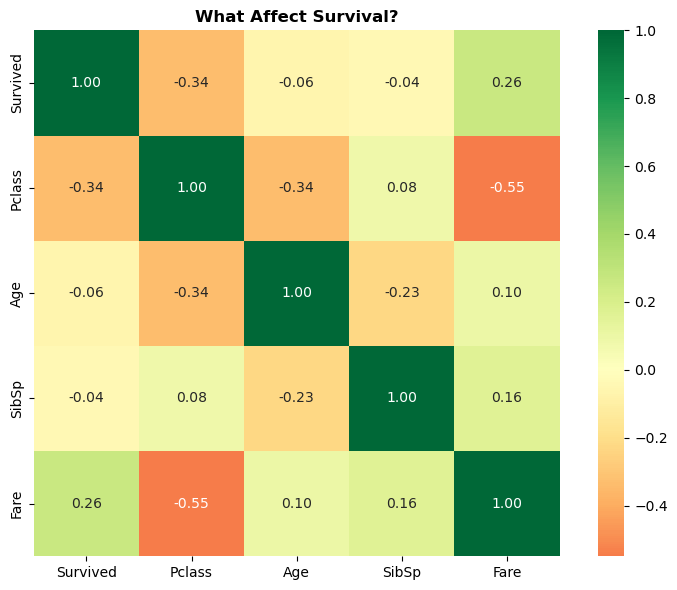

In [5]:
# Select only number columns

cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Fare' ]

corr = df[cols].corr()

print('CORRELATON MATRIX:')

print(corr.round(2))

print()

print('Reading the numbers:')

print('Near +1 = both go UP together')

print('Near 0 = NO relationship')

print('Near -1 = one goes UP, other goes DOWN')

print()

# Read specific values from the matrix

print(f'Fare vs Survived : {corr.loc["Survived", "Fare"]:.2f}')

print(f'Pclass vs Survived : {corr.loc["Survived", "Pclass"]:.2f}')

print(f'Age vs Survived : {corr.loc["Survived", "Age"]:.2f}')

# heatmap

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True, ax=ax)

ax.set_title('What Affect Survival?', fontweight='bold')

plt.tight_layout()

plt.savefig('stats_heatmap.png', dpi=100)

plt.show()

## Hypothesis Testing - is the class difference real or chance?

In [6]:
# Get survival data for first and third class

first = df[df['Pclass']==1]['Survived']
third = df[df['Pclass']==3]['Survived']

print(f'First class survival: {first.mean()*100:.1f}%')
print(f'Third class survival: {third.mean()*100:.1f}%')

# Run t-test

t, p = stats.ttest_ind(first, third)

print(f'P-value: {p:.6f}')
print()

print('What p-value means in simple words:')
print(' p < 0.05 = the difference is REAL, not by chance')
print(' p > 0.05 = the difference COULD be random')

if p < 0.05: 
    print('RESULT: YES - class significantly affected survival:')
    print('The difference between first and third class is NOT by chance.')
else : 
    print('RESULTL: NO significant difference found.')

First class survival: 63.0%
Third class survival: 24.2%
P-value: 0.000000

What p-value means in simple words:
 p < 0.05 = the difference is REAL, not by chance
 p > 0.05 = the difference COULD be random
RESULT: YES - class significantly affected survival:
The difference between first and third class is NOT by chance.


## Outlier Detection with IQR method

In [7]:
# Define a reusable function

def find_outliers(column, name):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    out = column[(column < low) | (column > high)]
    print(f'{name}: {len(out)} outliers found')
    print(f' Normal range: {low:.1f} to {high:.1f}')
    print()

# Call the function on different columns

find_outliers(df['Age'], 'Age')
find_outliers(df['Fare'], 'Fare')
find_outliers(df['SibSp'], 'SibSp')

Age: 66 outliers found
 Normal range: 2.5 to 54.5

Fare: 116 outliers found
 Normal range: -26.7 to 65.6

SibSp: 46 outliers found
 Normal range: -1.5 to 2.5



## Statistics Summary

In [8]:
print('='*50)

print('STATISTICS CHEAT SHEET')

print('='*50)

print()

print('CENTRAL TENDENCY:')

print('Mean = average. Use for symmetric data.')

print('Median = middle value. Use when outliers exist.')

print('Mode = most frequent value.')

print()

print('Std Dev = average distance from the mean.')

print('IQR = Q3 - Q1. Spread of middle 50%.')

print()

print('CORRELATION:')

print('+1 = perfect positive. -1 = perfect negative.')

print('0 = no relationship.')

print('WARNING: Correlation is NOT causation!')

print()

print('HYPOTHESIS TESTING:')

print('p < 0.05 = result is statistically significant.')

print('p > 0.05 = result could be by chance.')

print()

print('OUTLIERS:')

print('IQR method: below Q1-1.5*IQR or above Q3+1.5*IQR.')

print()

print('Day 8 COMPLETE! Statistics done.')

STATISTICS CHEAT SHEET

CENTRAL TENDENCY:
Mean = average. Use for symmetric data.
Median = middle value. Use when outliers exist.
Mode = most frequent value.

Std Dev = average distance from the mean.
IQR = Q3 - Q1. Spread of middle 50%.

CORRELATION:
+1 = perfect positive. -1 = perfect negative.
0 = no relationship.

HYPOTHESIS TESTING:
p < 0.05 = result is statistically significant.
p > 0.05 = result could be by chance.

OUTLIERS:
IQR method: below Q1-1.5*IQR or above Q3+1.5*IQR.

Day 8 COMPLETE! Statistics done.
